# TESS Light Curve Extraction

## Import section, configuration and defined functions 

### Import and logging initialization

In [1]:
%matplotlib widget
from dataclasses import dataclass
from pathlib import Path
import lightkurve as lk
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from astropy.table import Table
import numpy as np
import ipywidgets as widgets
import logging

TPF_CACHE_DIR = Path("__tpf")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s: %(message)s",
    filename="__extract.log",
    force=True
)

### Configuration class

In [2]:
@dataclass
class LCConfig:
    target: str
    sector: int
    cutout_size: int = 7
    aperture_file: str | None = None
    aperture_threshold: int = -1
    background_mask_file: str | None = None
    flatten_window_length: int = 401
    flatten_polyorder: int = 2
    save_products: bool = True
    output_dir: Path = Path('__output')

### Helper functions

In [3]:
def make_output_dir(cfg):
    cfg.output_dir.mkdir(parents=True, exist_ok=True)

def read_mask(file_name, expected_size):
    mask=np.loadtxt(file_name,dtype=bool,delimiter='\t')
    if mask.shape!=(expected_size,expected_size):
        raise ValueError(f'Mask shape {mask.shape}')
    return mask

def target_to_dirname(target: str) -> str:
    return target.replace(" ", "_").replace("/", "_").replace(":", "_")

def get_target_output_dir(cfg):
    d = cfg.output_dir / target_to_dirname(cfg.target)
    d.mkdir(parents=True, exist_ok=True)
    return d

def set_tpf_target_identity(tpf, target):
    """Make sure the TPF carries a proper target identity.

    TESSCut cutouts are built from RA/Dec, not from a catalog entry, so the
    downloaded FITS file has no TICID/OBJECT keyword and tpf.targetid stays
    None. That None then shows up in two places downstream:
      - the "Target ID: None" title in tpf.plot()  (uses tpf.targetid directly)
      - the "Value for TARGETID is None" warning when saving a lightcurve,
        since tpf.to_lightcurve() copies tpf.targetid into lc.meta["TARGETID"]

    Setting tpf.targetid here fixes both, since everything downstream reads
    from this one attribute. We also write TICID/OBJECT into the FITS header
    so that a *newly cached* file carries the correct identity too, and a
    plain TessTargetPixelFile(path) load (in this notebook or elsewhere)
    will recover it automatically next time via the TICID fallback.
    """
    digits = "".join(ch for ch in target if ch.isdigit())
    tic_id = int(digits) if digits else None
    tpf.targetid = tic_id if tic_id is not None else target
    tpf.hdu[0].header["OBJECT"] = target
    if tic_id is not None:
        tpf.hdu[0].header["TICID"] = tic_id
    return tpf

def load_or_download_tpf(cfg):
    target_dir = TPF_CACHE_DIR / target_to_dirname(cfg.target)
    target_dir.mkdir(parents=True, exist_ok=True)
    tpf_file = target_dir / f"s{cfg.sector:03d}_cut{cfg.cutout_size}.fits"
    if tpf_file.exists():
        logging.info(f"Using cached TPF: {tpf_file}")
        tpf = lk.TessTargetPixelFile(tpf_file)
        # Older cache files (created before this fix) may still lack TICID/OBJECT
        # in their header, so tpf.targetid can still come back None here -- set
        # it again defensively every time, regardless of cache hit or miss.
        return set_tpf_target_identity(tpf, cfg.target)
    logging.info(f"Downloading sector {cfg.sector}")
    search = lk.search_tesscut(cfg.target, sector=cfg.sector)
    if len(search) == 0:
        raise RuntimeError(f"No TESSCut found for {cfg.target}, sector {cfg.sector}")
    tpf = search.download(cutout_size=cfg.cutout_size)
    set_tpf_target_identity(tpf, cfg.target)
    tpf.to_fits(tpf_file, overwrite=True)
    logging.info(f"Saved cache: {tpf_file}")
    return tpf

def plot_lc_plotly(lc, title, filename=None):
    """Interactive Plotly view of a lightcurve, with an optional saved HTML copy.

    Unlike ApertureBuilder, this is a plain visualization of a finished result
    (no click-to-edit logic), so a self-contained HTML file (fig.write_html)
    is a perfectly faithful save -- nothing here depends on a live Python
    kernel the way clicking pixels in ApertureBuilder does.
    """
    time = np.asarray(lc.time.value)
    flux = np.asarray(lc.flux)
    fig = go.Figure()
    #fig.update_layout(title=title, xaxis_title=f"Time [{lc.time.format.upper()}]", yaxis_title="Flux", width=900, height=500)
    if "flux_err" in lc.colnames and np.any(np.isfinite(lc.flux_err)):
        flux_err = np.asarray(lc.flux_err)
        fig.add_trace(go.Scatter(
            x=time, y=flux, mode="markers",
            error_y=dict(type="data", array=flux_err, visible=True, color="gray", thickness=0.5),
            marker=dict(size=6), name="flux"
        ))
    else:
        fig.add_trace(go.Scatter(x=time, y=flux, mode="markers", marker=dict(size=4), name="flux"))
    fig.update_layout(title=title, xaxis_title=f"Time [{lc.time.format.upper()}]", yaxis_title="Flux")
    if filename is not None:
        fig.write_html(filename)
    fig.show()
    ##return fig

def save_lcv_ascii(lc, filename):
    tbl = lc.to_table()
    flux = np.asarray(tbl["flux"])
    good = flux > 0
    bjd_tdb = tbl["time"] + 2457000.0
    btjd = tbl["time"]
    mag = np.full(len(flux), np.nan, dtype=float)
    mag[good] = -2.5 * np.log10(flux[good])
    mag -= np.nanmedian(mag)
    flux_err = np.full(len(flux), 0, dtype=float)
    mag_err = np.full(len(flux), np.nan, dtype=float)
    mag_err[good] = 0
    if "flux_err" in tbl.colnames:
        flux_err = np.asarray(tbl["flux_err"])
        mag_err[good] = 2.5 / np.log(10) * flux_err[good] / flux[good]
    out = Table()
    out["BJD_TDB"] = bjd_tdb
    out["mag"] = mag
    out["mag_err"] = mag_err
    out["BTJD"] = btjd
    out["flux"] = tbl["flux"]
    out["flux_err"] = flux_err
    if "quality" in tbl.colnames:
        out["quality"] = tbl["quality"]
    if "cadenceno" in tbl.colnames:
        out["cadenceno"] = tbl["cadenceno"]
    out.write(filename, format="ascii.tab", overwrite=True)

### Aperture builder

In [4]:
class ApertureBuilder:
    """Interactive aperture-mask builder.

    Click pixels on the image to toggle them in/out of the aperture.
    Because building the mask requires user interaction, this class does
    NOT return a finished mask right away: create it in one cell, click
    on the pixels you want, then read `.mask` from a LATER cell once you
    are done clicking. Trying to use the mask in the same cell where the
    builder is created will always give you an empty (all-False) mask,
    because the click events haven't happened yet at that point.
    """

    def __init__(self, tpf):
        self.tpf = tpf
        image = np.nanmedian(tpf.flux.value, axis=0)
        self.ny, self.nx = image.shape
        self.mask = np.zeros((self.ny, self.nx), dtype=bool)

        self.fig, self.ax = plt.subplots(figsize=(6, 6))
        self.ax.figure.canvas.header_visible = False
        self.img = self.ax.imshow(image, origin="lower")
        self.overlay = self.ax.imshow(
            np.where(self.mask, 1.0, np.nan),
            origin="lower", alpha=0.7, cmap="magma", vmin=0, vmax=1
        )
        plt.colorbar(self.img, ax=self.ax)
        self.ax.set_title("Click pixels to toggle aperture, then run the next cell")
        # Flip the display only -- event.xdata/event.ydata are transformed through
        # the axes' own coordinate system, so inverting the y-axis here does not
        # change which (row, col) a click maps to in self.mask.
        self.ax.invert_yaxis()

        self.status = widgets.Output()
        display(self.status)
        self._report()

        self.cid = self.fig.canvas.mpl_connect("button_press_event", self._onclick)

    def _report(self):
        with self.status:
            self.status.clear_output(wait=True)
            print("Selected pixels:", int(np.sum(self.mask)))

    def _onclick(self, event):
        if event.inaxes != self.ax:
            return
        x = int(round(event.xdata))
        y = int(round(event.ydata))
        if x < 0 or x >= self.nx or y < 0 or y >= self.ny:
            return
        self.mask[y, x] = ~self.mask[y, x]
        self.overlay.set_data(np.where(self.mask, 1.0, np.nan))
        self.fig.canvas.draw_idle()
        self._report()


def build_aperture_interactive(tpf):
    """Deprecated shim: kept for backward compatibility.

    This can no longer "return the finished mask" synchronously -- see
    ApertureBuilder above for why. Use ApertureBuilder directly instead:

        builder = build_aperture_interactive(tpf)   # run this cell, click pixels
        # ... in a LATER cell, once you're done clicking:
        aperture = builder.mask
    """
    return ApertureBuilder(tpf)


### Background subtraction

In [5]:
def estimate_background(image, background_mask=None):
    # NaN-safe: TESS cutouts commonly have NaN pixels at the edges (outside the
    # available data). Plain np.percentile/np.mean propagate NaN, which would
    # silently turn the estimated background (and then the whole frame's flux)
    # into NaN. Use the nan-aware variants instead.
    if background_mask is not None:
        return np.nanmean(image[background_mask])
    threshold = np.nanpercentile(image, 10)
    return np.nanmean(image[image <= threshold])

def subtract_background(tpf, background_mask=None):
    flux=np.array(tpf.hdu[1].data['FLUX'], copy=True)
    backgrounds=np.array([estimate_background(img, background_mask) for img in flux])
    flux -= backgrounds[:,None,None]
    tpf.hdu[1].data['FLUX']=flux
    return tpf

### Main extraction function

In [6]:
def extract_lc(cfg, aperture=None):
    make_output_dir(cfg)
    tpf=load_or_download_tpf(cfg)
    if aperture is None:
        # Fall back to file/threshold-based aperture; interactive apertures must
        # be built beforehand (see ApertureBuilder) since they need user clicks
        # across separate cells and can't be produced synchronously here.
        # aperture_threshold < 0 is the sentinel for "interactive mode" (see
        # ApertureBuilder) -- it must NOT be passed to create_threshold_mask,
        # since a negative threshold doesn't error, it just silently selects
        # almost every pixel in the cutout.
        if cfg.aperture_file:
            aperture = read_mask(cfg.aperture_file, cfg.cutout_size)
        elif cfg.aperture_threshold is not None and cfg.aperture_threshold >= 0:
            aperture = tpf.create_threshold_mask(threshold=cfg.aperture_threshold)
        else:
            raise RuntimeError(
                f"No aperture provided for {cfg.target}, sector {cfg.sector}, and cfg has "
                "no aperture_file or non-negative aperture_threshold. Build one with "
                "ApertureBuilder first and pass aperture=builder.mask."
            )
    aperture = np.asarray(aperture, dtype=bool)
    if np.sum(aperture) == 0:
        raise RuntimeError(f"Aperture mask is empty for {cfg.target}, sector {cfg.sector}. Check the aperture file or threshold.")
    #print(f"Aperture mask shape: {aperture.shape}, sum: {np.sum(aperture)}")
    background_mask = read_mask(cfg.background_mask_file, cfg.cutout_size) if cfg.background_mask_file else None
    tpf=subtract_background(tpf, background_mask)
    lc=tpf.to_lightcurve(aperture_mask=aperture)
    lc_flat=lc.flatten(window_length=cfg.flatten_window_length, polyorder=cfg.flatten_polyorder).normalize()
    if cfg.save_products:
        target_output_dir = get_target_output_dir(cfg)
        prefix = target_output_dir / f"s{cfg.sector:03d}_cut{cfg.cutout_size}"
        tpf.to_fits(str(prefix) + "_tpf_no_background.fits", overwrite=True)
        lc.to_fits(str(prefix) + "_lc.fits", overwrite=True)
        lc_flat.to_fits(str(prefix) + "_flat.fits", overwrite=True)
        save_lcv_ascii(lc, str(prefix) + "_lc.txt")
        save_lcv_ascii(lc_flat, str(prefix) + "_flat.txt")
        # Same delimiter/format as read_mask expects, so the saved file can be
        # fed straight back in via cfg.aperture_file next time.
        np.savetxt(str(prefix) + "_aperture.txt", aperture, fmt="%d", delimiter="\t")
        logging.info("Saved products for sector %s", cfg.sector)
    return tpf, lc, lc_flat, aperture, background_mask

## <font color="00FF00">Define TARGET</font>

In [7]:
#TARGET='Gaia DR3 2014109662039066880'
#TARGET='TIC_269112450'
#TARGET='TIC 183374187'  # Exoplanet target for testing
#TARGET='V405 Dra'
TARGET='AM Her'
#TARGET='TIC 269112631' #PMAK V150


## <font color="00FF00">Search available sectors</color>

In [8]:
search_result=lk.search_tesscut(TARGET)
print(search_result)

SearchResult containing 14 data products.

 #     mission     year  author exptime target_name distance
                                   s                 arcsec 
--- -------------- ---- ------- ------- ----------- --------
  0 TESS Sector 14 2019 TESScut    1426      AM Her      0.0
  1 TESS Sector 26 2020 TESScut    1426      AM Her      0.0
  2 TESS Sector 25 2020 TESScut    1426      AM Her      0.0
  3 TESS Sector 41 2021 TESScut     475      AM Her      0.0
  4 TESS Sector 40 2021 TESScut     475      AM Her      0.0
  5 TESS Sector 58 2022 TESScut     158      AM Her      0.0
  6 TESS Sector 53 2022 TESScut     475      AM Her      0.0
  7 TESS Sector 52 2022 TESScut     475      AM Her      0.0
  8 TESS Sector 54 2022 TESScut     475      AM Her      0.0
  9 TESS Sector 75 2024 TESScut     158      AM Her      0.0
 10 TESS Sector 79 2024 TESScut     158      AM Her      0.0
 11 TESS Sector 80 2024 TESScut     158      AM Her      0.0
 12 TESS Sector 81 2024 TESScut     158   

## <font color="00FF00">Run extraction</font>

#### <font color="00FF00">Configure and run this cell **first**!</font>

Modes:
* Interactive aperture selection: aperture_threshold and aperture_file both commented out
* Auto-define the aperture using a threshold: uncomment aperture_threshold
* Aperture from a file: uncomment the aperture_file definition and set the correct filename.

0% (10/3668) of the cadences will be ignored due to the quality mask (quality_bitmask=175).


Output()

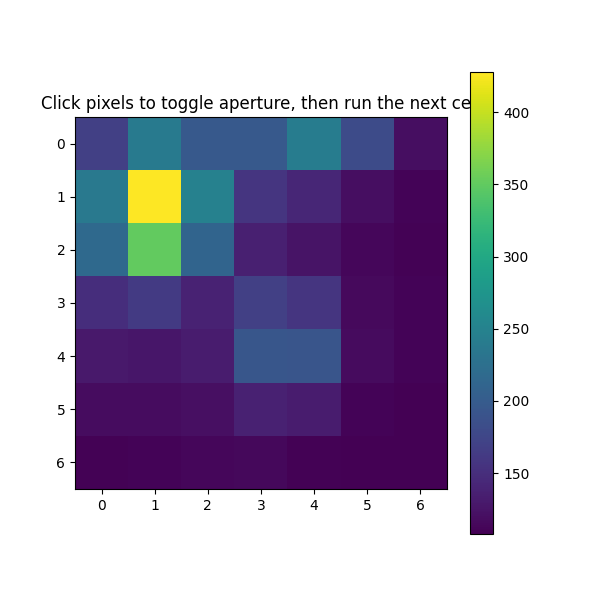

In [9]:
# Set aperture_threshold to negative or comment it out and comment out the aperture_file line to use the interactive aperture builder
cfg=LCConfig(
    flatten_window_length = 101, # Lightkurve default
    flatten_polyorder = 2,       # Lightkurve default
    #save_products=False,
    target=TARGET,
    sector=41,
    cutout_size=7,
    #aperture_threshold=5,
    #background_mask_file='bk-mask.txt',
    #aperture_file='aperture.txt'
)

# Build/load the TPF and open the interactive aperture editor.
# Click pixels in the plot to toggle them, watch the "Selected pixels" counter,
# then move on to the NEXT cell only once you're happy with the aperture.
if cfg.aperture_file is None and cfg.aperture_threshold < 0:
    tpf = load_or_download_tpf(cfg)
    builder = ApertureBuilder(tpf)
else:
    builder = None


#### <font color="#00FF00">Run this cell **after** defining the aperture (in the previous cell)</font>

0% (10/3668) of the cadences will be ignored due to the quality mask (quality_bitmask=175).


Aperture


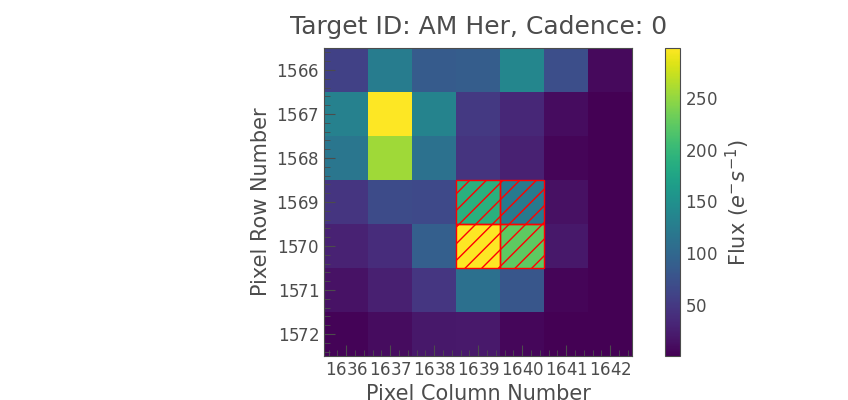

Light Curve


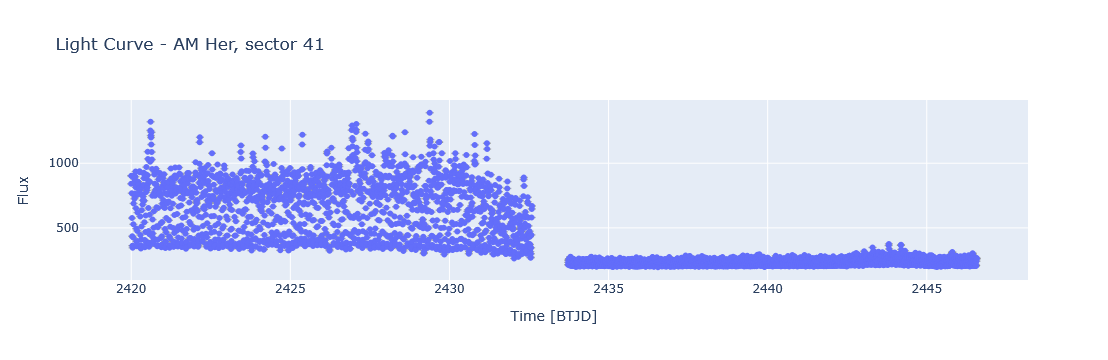

Flattened Light Curve


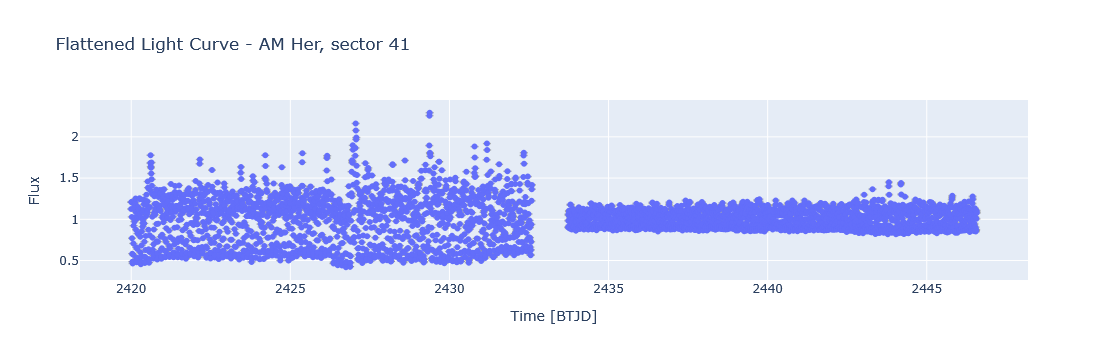

In [11]:
# Run this cell AFTER you've finished clicking pixels in the cell above.
aperture = builder.mask if builder is not None else None
tpf, lc, lc_flat, aperture, background_mask = extract_lc(cfg, aperture=aperture)
print("Aperture")
ax = tpf.plot(aperture_mask=aperture); ax.invert_yaxis(); ax.figure.canvas.header_visible = False; plt.show()
target_output_dir = get_target_output_dir(cfg)
prefix = target_output_dir / f"s{cfg.sector:03d}_cut{cfg.cutout_size}"
print("Light Curve")
plot_lc_plotly(lc, f"Light Curve - {cfg.target}, sector {cfg.sector}", filename=str(prefix) + "_lc.html")
print("Flattened Light Curve")
plot_lc_plotly(lc_flat, f"Flattened Light Curve - {cfg.target}, sector {cfg.sector}", filename=str(prefix) + "_flat.html")
